# Stock Market Analytics Zoomcamp — Module 2 homework

**Santiago Parada · Analysis date: 11 September 2026**

This notebook answers Q1–Q5 and shows the calculations. Run the cells from top to bottom in Google Colab or Jupyter. The live IPO pages and Yahoo histories can change; outputs state the counts actually observed. The RSI parquet is downloaded from the homework's public Google Drive link if it is not already alongside this notebook. No private credentials are needed.

**Answers from the source data available on 28 September 2026:** Q1 Acquisition Corp, **$499.985 million**; Q2 median assignment-defined score **0.04801** as written (**0.04643** if infinite scores are excluded); Q3 **1 month, 0.93062×** (−6.94%); Q4 **$65.806 thousand**; Q5 a point-in-time, out-of-sample IPO screening proposal. Earlier calculations quoted 0.05014 and 0.93535× for Q2/Q3, but those exact values are **not reproduced** by this rerun. The cells recompute the answers from the data available when they are run.

## Setup and assumptions

- [IPOScoop recently filed](https://www.iposcoop.com/ipos-recently-filed/) and [2025 pricings](https://www.iposcoop.com/2025-pricings/) are live tables, not archived point-in-time snapshots.
- **Q1:** “before September 11” means file dates **strictly before 2026-09-11**. Name rules are applied in the order given. The result is a proposed *offering value* in millions of dollars, not investors' realized loss.
- **Q2–Q3:** Prices end on **2026-09-11 inclusive**. A month is exactly 21 trading observations. `Close` is the unadjusted daily close, as requested. Yahoo may omit or reuse delisted symbols.
- **Q4:** Each qualifying row is a separate hypothetical $1,000 trade. `growth_future_30d` is a **30-observation** future growth multiple as supplied by the parquet; overlapping positions and execution costs are not modeled.
- The assignment calls its Q2 expression a “Sharpe ratio,” but its denominator is the standard deviation of **price levels**. It is **not** the conventional Sharpe ratio of returns.

In [1]:
# Colab: uncomment this line if a package is missing.
# %pip install -q pandas numpy lxml yfinance requests pyarrow gdown matplotlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from io import StringIO
import re
import time
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

AS_OF = pd.Timestamp('2026-09-11')
END_EXCLUSIVE = pd.Timestamp('2026-09-12')
IPO_CUTOFF = pd.Timestamp('2025-09-01')
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.grid': True,
                     'axes.spines.top': False, 'axes.spines.right': False})

## Q1 — Withdrawn IPOs by company name

In [2]:
RECENT_URL = 'https://www.iposcoop.com/ipos-recently-filed/'
recent = pd.read_html(RECENT_URL)[0]
required = {'File Date', 'Company', 'Shares (millions)', 'Price Low',
            'Price High', 'Est $ Vol (millions)', 'Expected To Trade'}
assert required.issubset(recent.columns), f'Unexpected source columns: {recent.columns.tolist()}'

withdrawn_all = recent.loc[
    recent['Expected To Trade'].astype(str).str.strip().eq('Withdrawn')
].copy()
withdrawn_all['File Date'] = pd.to_datetime(withdrawn_all['File Date'], errors='coerce')
withdrawn = withdrawn_all.loc[withdrawn_all['File Date'] < AS_OF].copy()
print(f'Live table: {len(recent)} filings; {len(withdrawn_all)} withdrawn overall; '
      f'{len(withdrawn)} withdrawn with file dates before {AS_OF.date()}.')
print('The assignment expected 32; a live table may have a different count.')

Live table: 500 filings; 35 withdrawn overall; 31 withdrawn with file dates before 2026-09-11.
The assignment expected 32; a live table may have a different count.


In [3]:
# First matching pattern wins. We use literal substring matches (case-insensitive)
# in the specified order: Technology does not match Technologies.
COMPANY_PATTERNS = [
    ('Technologies', ('Technologies',)),
    ('Acquisition Corp', ('Acquisition Corp', 'Acquisition Corporation', 'Corp')),
    ('Inc.', ('Inc', 'Incorporated')),
    ('Group', ('Group',)),
    ('Limited', ('Ltd', 'Limited')),
    ('Holdings', ('Holdings', 'Holding')),
]
def company_type(name):
    name = str(name).casefold()
    return next((label for label, patterns in COMPANY_PATTERNS
                 if any(pattern.casefold() in name for pattern in patterns)), 'Other')

def number(value):
    # Coerce blank, '-', and missing values to NaN.
    return pd.to_numeric(pd.Series(value).astype(str).str.replace(r'[$,]', '', regex=True),
                         errors='coerce')

assert company_type('EUPEC International Group Ltd.') == 'Group'
assert company_type('Xinxu Copper Industry Technology Ltd.') == 'Limited'
withdrawn['Company Type'] = withdrawn['Company'].map(company_type)
for column in ['Price Low', 'Price High', 'Shares (millions)', 'Est $ Vol (millions)']:
    withdrawn[column] = number(withdrawn[column]).to_numpy()

# Require both quotes for the average. An incomplete range falls back to
# the estimated value, rather than silently accepting one quoted price.
withdrawn['Avg_price'] = withdrawn[['Price Low', 'Price High']].mean(axis=1, skipna=False)
withdrawn['Shares_offered_value'] = (
    withdrawn['Shares (millions)'] * withdrawn['Avg_price']
).fillna(withdrawn['Est $ Vol (millions)'])
totals = withdrawn.groupby('Company Type')['Shares_offered_value'].agg(
    IPOs='count', **{'Value ($ million)': 'sum'}
).sort_values('Value ($ million)', ascending=False)
display(totals.round(3))
leader, leader_value = totals.index[0], totals.iloc[0]['Value ($ million)']
print(f'Q1: {leader} — ${leader_value:,.3f} million')

Q1: Acquisition Corp — $499.985 million


,IPOs,Value ($ million)
Company Type,,
Acquisition Corp,5,499.985
Inc.,1,351.000
Holdings,4,311.658
Other,8,290.445
Limited,7,197.250
Technologies,3,184.900
Group,3,32.500


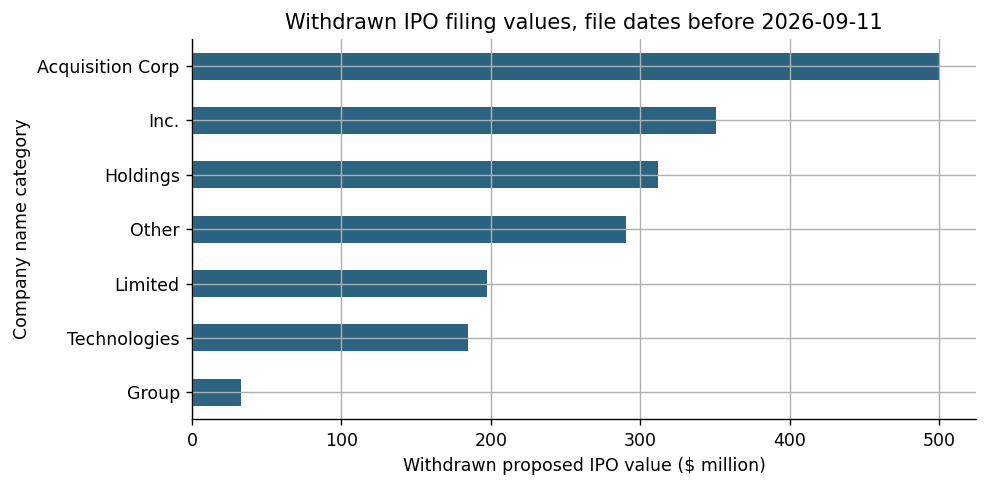

In [4]:
ax = totals['Value ($ million)'].sort_values().plot.barh(color='#2c6380')
ax.set(xlabel='Withdrawn proposed IPO value ($ million)', ylabel='Company name category',
       title=f'Withdrawn IPO filing values, file dates before {AS_OF.date()}')
plt.tight_layout(); plt.show()

## Q2 — 2025 IPO cohort and the assignment-defined “Sharpe”

The page's `Return` column is used **only to select tickers** in accordance with the homework. This is later-known information and would bias a real strategy formed on the IPO date. We do not use it to compute price performance.

In [5]:
PRICINGS_URL = 'https://www.iposcoop.com/2025-pricings/'
ipos_2025 = pd.read_html(PRICINGS_URL)[0]
assert {'Symbol', 'Offer Date', 'Return'}.issubset(ipos_2025.columns)
ipos_2025['Offer Date'] = pd.to_datetime(ipos_2025['Offer Date'], errors='coerce')
ipos_2025['return_pct'] = number(ipos_2025['Return'].astype(str).str.replace('%', '', regex=False))
cohort = ipos_2025.loc[
    (ipos_2025['Offer Date'] < IPO_CUTOFF) &
    (ipos_2025['return_pct'].notna()) & (ipos_2025['return_pct'] != 0) &
    (ipos_2025['Symbol'].notna())
].copy()
symbols = cohort['Symbol'].astype(str).str.strip().drop_duplicates().tolist()
print(f'{len(ipos_2025)} 2025 rows; {len(cohort)} filtered rows; '
      f'{len(symbols)} distinct symbols (assignment checkpoint: 148).')

231 2025 rows; 146 filtered rows; 146 distinct symbols (assignment checkpoint: 148).


### Download daily Yahoo OHLCV histories

The function below calls Yahoo's daily chart endpoint, the same history underlying `yfinance`, because high-level `yfinance.download()` can return HTTP 429 in this environment. It retains the original daily **Close** and ignores missing symbols. For an independent verification, `yf.download(symbol, start=..., end=..., auto_adjust=False)` can be used for a sample ticker. The results are cached in `yahoo_ipo_cache/` for a rerun; the cache is optional and is not needed to upload this notebook to GitHub.

In [6]:
CACHE_DIR = Path('yahoo_ipo_cache')
CACHE_DIR.mkdir(exist_ok=True)
period2 = int(END_EXCLUSIVE.tz_localize('UTC').timestamp())

def fetch_history(symbol):
    cache = CACHE_DIR / f'{symbol.replace("/", "_")}_to_{AS_OF.date()}.csv'
    if cache.exists():
        data = pd.read_csv(cache, parse_dates=['Date'])
        return symbol, data, None
    url = f'https://query1.finance.yahoo.com/v8/finance/chart/{symbol}'
    params = {'period1': 0, 'period2': period2, 'interval': '1d',
              'events': 'history', 'includeAdjustedClose': 'false'}
    error = None
    for attempt in range(3):
        try:
            response = requests.get(url, params=params, timeout=25,
                                    headers={'User-Agent': 'Mozilla/5.0'})
            if response.status_code in (404, 429):
                error = f'HTTP {response.status_code}'
                if response.status_code == 429: time.sleep(2 ** attempt)
                continue
            response.raise_for_status()
            root = response.json()['chart']
            if not root.get('result'):
                return symbol, None, str(root.get('error'))
            result = root['result'][0]
            quote = result['indicators']['quote'][0]
            dates = pd.to_datetime(result['timestamp'], unit='s', utc=True).tz_convert(
                result['meta'].get('exchangeTimezoneName', 'America/New_York')).date
            data = pd.DataFrame({'Date': pd.to_datetime(dates), 'Symbol': symbol,
                                 'Open': quote['open'], 'High': quote['high'],
                                 'Low': quote['low'], 'Close': quote['close'],
                                 'Volume': quote['volume']})
            data = data.loc[(data['Date'] <= AS_OF) & data['Close'].notna()].sort_values('Date')
            if data.empty: return symbol, None, 'No valid daily close'
            data.to_csv(cache, index=False)
            return symbol, data, None
        except (requests.RequestException, KeyError, ValueError, TypeError) as exc:
            error = str(exc)[:100]
            time.sleep(2 ** attempt)
    return symbol, None, error

histories, failed = {}, {}
with ThreadPoolExecutor(max_workers=5) as pool:
    for symbol, data, error in pool.map(fetch_history, symbols):
        if data is None: failed[symbol] = error
        else: histories[symbol] = data
if not histories:
    raise RuntimeError('No Yahoo histories downloaded; try again later or use a local cache.')
stocks_df = pd.concat(histories.values(), ignore_index=True).sort_values(['Symbol', 'Date'])
assert not stocks_df.duplicated(['Symbol', 'Date']).any()
print(f'{len(histories)} symbols with data, {len(failed)} unavailable; '
      f'{len(stocks_df):,} daily rows. Missing examples: {list(failed.items())[:8]}')

131 symbols with data, 15 unavailable; 66,466 daily rows. Missing examples: [('MJID', 'HTTP 404'), ('DLXY', "'timestamp'"), ('EMPG', 'HTTP 404'), ('CAEP', 'HTTP 404'), ('PTNM', 'HTTP 404'), ('AHL', 'HTTP 404'), ('CEPT', 'HTTP 404'), ('SDM', 'HTTP 404')]


In [7]:
by_symbol = stocks_df.groupby('Symbol', sort=False)['Close']
stocks_df['growth_252d'] = by_symbol.transform(lambda close: close / close.shift(252))
stocks_df['volatility'] = by_symbol.transform(
    lambda close: close.rolling(30).std() * np.sqrt(252)
)
stocks_df['Sharpe'] = (stocks_df['growth_252d'] - 0.05) / stocks_df['volatility']
on_date = stocks_df.loc[stocks_df['Date'].eq(AS_OF)].copy()
# Preserve infinity for the exact assignment expression and report it explicitly.
# A constant 30-day price window has zero denominator, so infinity is not an
# economically meaningful risk-adjusted return.
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    stats = on_date[['growth_252d', 'volatility', 'Sharpe']].describe()
display(stats)
finite_sharpe = on_date['Sharpe'].replace([np.inf, -np.inf], np.nan)
print(f'Q2: median as written = {on_date.Sharpe.median():.5f}; '
      f'finite-only median = {finite_sharpe.median():.5f}; '
      f'{np.isinf(on_date.Sharpe).sum()} infinite scores; '
      f'{on_date.growth_252d.count()} valid 252-day growth observations.')

Q2: median as written = 0.04801; finite-only median = 0.04643; 4 infinite scores; 129 valid 252-day growth observations.


,growth_252d,volatility,Sharpe
count,129.000000,130.000000,129.000000
mean,1.059676,27.752883,NaN
std,3.059882,67.094696,NaN
min,0.001005,0.000000,-inf
25%,0.149038,2.292223,0.011942
50%,0.596026,8.122327,0.048009
75%,1.040233,24.019924,0.134248
max,33.638270,627.698106,inf


Median vs mean growth: 0.596026478041254 1.059676320740792


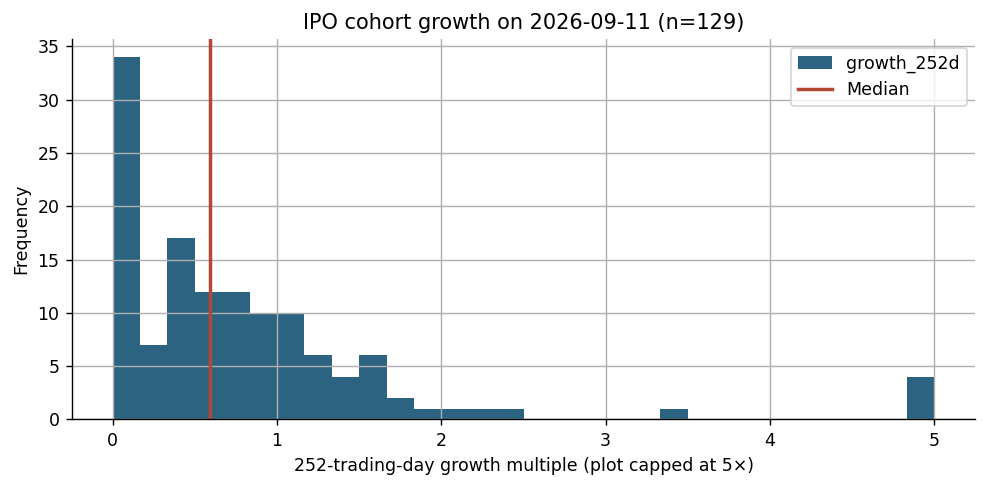

,Symbol,growth_252d,Sharpe
14673,HCMAU,1.035,5.385
1311,CEPF,1.024,2.771
31264,TMDE,0.776,1.751
22613,TLIH,0.990,1.449
65620,CEPO,1.031,1.234
32322,HXHX,0.410,0.753
58223,FBGL,0.577,0.629
1577,ETS,1.559,0.526


In [8]:
view = on_date['growth_252d'].dropna().clip(upper=5)
ax = view.plot.hist(bins=30, color='#2c6380')
ax.axvline(on_date['growth_252d'].median(), color='#b44734', label='Median', linewidth=2)
ax.set(xlabel='252-trading-day growth multiple (plot capped at 5×)',
       title=f'IPO cohort growth on {AS_OF.date()} (n={len(view)})')
ax.legend(); plt.tight_layout(); plt.show()
print('Median vs mean growth:', on_date['growth_252d'].median(),
      on_date['growth_252d'].mean())
display(on_date.assign(Sharpe=finite_sharpe)[['Symbol', 'growth_252d', 'Sharpe']].dropna()
        .sort_values('Sharpe', ascending=False).head(8).round(3))

## Q3 — Holding a stock for 1–12 fixed 21-day months

The start is the first date in the **available Yahoo history**, which can precede the IPO for a reused symbol. This follows the assignment's `min_date` instruction but is a data-quality concern. The count at 12 months can be lower because later listings have not yet accumulated 252 trading days.

In [9]:
growth_cols = []
for month in range(1, 13):
    column = f'future_growth_{month}_m'
    growth_cols.append(column)
    stocks_df[column] = stocks_df.groupby('Symbol', sort=False)['Close'].shift(-21 * month) / stocks_df['Close']

min_dates = stocks_df.groupby('Symbol', as_index=False).agg(min_date=('Date', 'min'))
ipo_entries = min_dates.merge(stocks_df, left_on=['Symbol', 'min_date'],
                              right_on=['Symbol', 'Date'], how='inner', validate='one_to_one')
holding_stats = ipo_entries[growth_cols].describe().T
holding_stats.index = pd.Index(range(1, 13), name='Holding months')
display(holding_stats[['count', 'mean', '50%', 'min', 'max']].round(4))
best_month = int(holding_stats['50%'].idxmax())
best_multiple = float(holding_stats.loc[best_month, '50%'])
print(f'Q3: {best_month} month(s); median growth {best_multiple:.5f}×; '
      f'median return {(best_multiple - 1):+.2%}')

# Audit histories that begin before the stated 2025 IPO cohort.
early = ipo_entries.loc[ipo_entries['min_date'] < pd.Timestamp('2025-01-01'),
                        ['Symbol', 'min_date']]
print(f'{len(early)} symbols have pre-2025 Yahoo histories:')
display(early.head(12))

Q3: 1 month(s); median growth 0.93062×; median return -6.94%
5 symbols have pre-2025 Yahoo histories:


,count,mean,50%,min,max
Holding months,,,,,
1,131.0,1.1205,0.9306,0.0729,9.4660
2,130.0,1.2959,0.8902,0.1062,16.0668
3,130.0,1.2593,0.8280,0.0901,16.3445
4,130.0,1.1413,0.7499,0.0639,11.3866
5,130.0,1.0894,0.6833,0.0322,9.4951
6,130.0,1.1197,0.7135,0.0221,9.8946
7,130.0,1.1513,0.6610,0.0132,20.7415
8,130.0,1.0075,0.6040,0.0151,21.3708
9,130.0,1.1631,0.5844,0.0147,27.6273


,Symbol,min_date
5,ALM,2013-06-17
13,AVBH,2004-07-12
21,CAPS,1993-01-28
28,CIIT,2013-10-10
99,PPCB,2013-01-07


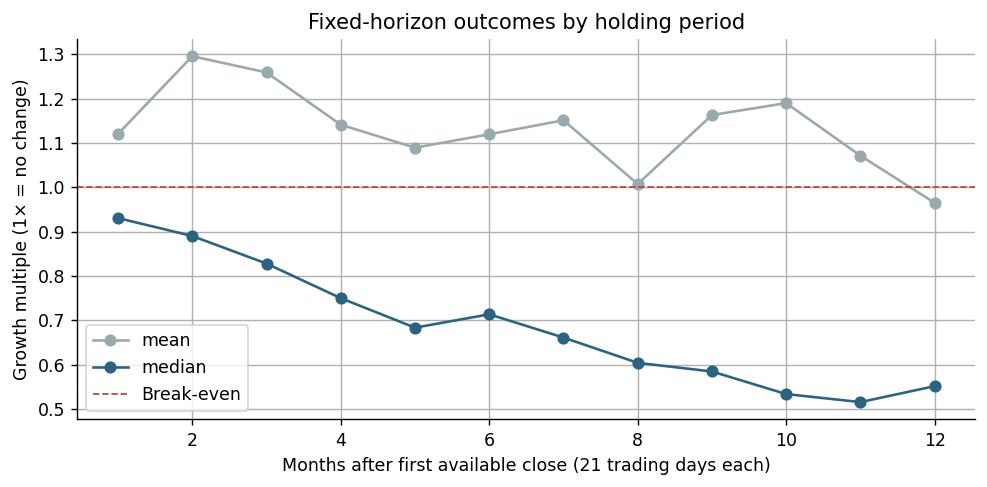

In [10]:
ax = holding_stats[['mean', '50%']].rename(columns={'50%': 'median'}).plot(
    marker='o', color=['#9aa9ad', '#2c6380'])
ax.axhline(1, color='#b44734', linestyle='--', linewidth=1, label='Break-even')
ax.set(xlabel='Months after first available close (21 trading days each)',
       ylabel='Growth multiple (1× = no change)',
       title='Fixed-horizon outcomes by holding period')
ax.legend(); plt.tight_layout(); plt.show()

## Q4 — RSI < 30, $1,000 per signal

Source: the [course's public parquet dataset](https://drive.google.com/file/d/1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-/view). It can be large. If Colab cannot fetch it automatically, download it in the browser and upload it to the notebook's working directory as `data.parquet`, then rerun this section. The summary previously observed for this homework was **5,206 qualifying trades and $65,806 gross profit**; the code below recalculates rather than inserting that number into the result.

In [11]:
RSI_FILE = Path('data.parquet')
if not RSI_FILE.exists():
    import gdown
    try:
        downloaded = gdown.download(
            id='1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-',
            output=str(RSI_FILE), quiet=False)
    except Exception as exc:
        downloaded = None
        warnings.warn(f'RSI parquet unavailable: {exc}')
if RSI_FILE.exists():
    rsi_df = pd.read_parquet(RSI_FILE, engine='pyarrow')
    print('RSI data:', rsi_df.shape)
    print('Relevant columns:', [c for c in rsi_df.columns
                                if 'rsi' in c.lower() or 'growth_future_30d' in c.lower() or 'date' in c.lower()])
else:
    rsi_df = None
    print('Q4 data not downloaded. Upload data.parquet and rerun this section.')

RSI data: (229932, 203)
Relevant columns: ['Date', 'growth_future_30d', 'rsi', 'fastk_rsi', 'fastd_rsi', 'cdl3starsinsouth']


In [12]:
if rsi_df is not None:
    rsi_column = next((c for c in rsi_df.columns if str(c).lower() == 'rsi'), None)
    if rsi_column is None:
        raise KeyError('Expected an RSI column named rsi; inspect the listed columns above.')
    if 'Date' in rsi_df.columns:
        trade_dates = pd.to_datetime(rsi_df['Date'], errors='coerce')
    elif 'date' in rsi_df.columns:
        trade_dates = pd.to_datetime(rsi_df['date'], errors='coerce')
    else:
        trade_dates = pd.to_datetime(rsi_df.index, errors='coerce')
    trade_dates = pd.Series(trade_dates, index=rsi_df.index)
    if getattr(trade_dates.dt, 'tz', None) is not None:
        trade_dates = trade_dates.dt.tz_localize(None)
    mask = (trade_dates.between('2000-01-01', '2025-06-01') &
            (pd.to_numeric(rsi_df[rsi_column], errors='coerce') < 30) &
            rsi_df['growth_future_30d'].notna())
    selected_df = rsi_df.loc[mask].copy()
    growth = pd.to_numeric(selected_df['growth_future_30d'], errors='coerce').dropna()
    trade_profit = 1000 * (growth - 1)
    net_income = float(trade_profit.sum())
    print(f'Q4: {len(growth):,} trades; net income ${net_income:,.2f} '
          f'= ${net_income/1000:,.3f} thousand')
    print(f'Mean return {(growth.mean()-1):.3%}; win rate {(growth.gt(1).mean()):.2%}; '
          f'mean profit ${trade_profit.mean():.2f}/signal')
else:
    print('Q4 not recomputed: place data.parquet beside this notebook and rerun.')

Q4: 5,206 trades; net income $65,805.59 = $65.806 thousand
Mean return 1.264%; win rate 55.13%; mean profit $12.64/signal


## Q5 — Improving a future IPO strategy

1. **Choose features known before entry:** offer size, sector, prospectus disclosures, valuation versus peers, IPO pricing revision, first-day liquidity and spread. Record the timestamp and make the entry *after* all selected information is observable.
2. **Compare against an honest baseline:** no trade, a broad market ETF, and a simple equal-weight IPO basket. Evaluate later IPO cohorts that were not used to select the rules.
3. **Keep failures in the universe:** withdrawn offerings are not trades; delisted tickers, trading halts, splits, and ticker changes must remain accounted for. Do not select historical IPOs using their later `Return` column.
4. **Trade only when expected return clears costs and risk:** estimate bid–ask spread, fees, simultaneous capital, median return, downside, maximum drawdown, and net return on committed capital. A one-month median below 1× is a reason to test a selective screen, not a reason to buy every IPO.

**Caveat:** RSI gross profit adds $1,000 for each signal; it does not mean that a single $1,000 account earned $65,806. Repeated signals on the same ticker and overlapping trades require a portfolio ledger before calling the strategy investable.